In [1]:
import pandas as pd

# ファイルパスを適宜修正してください
file1 = "output_中間発表.csv"  # データ1
file2 = "result_grid_mnist_中間発表.csv"  # データ2
file3 = "result_grid_fashion_mnist_中間発表.csv"  # データ3

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)
df3 = pd.read_csv(file3)

# Grouping keys
keys = ["dataset", "F_type", "G_type", "lw_alpha", "anchor_method", "data_distribution"]

# データ1の平均値をキーごとに算出
mean_df = (
    df1.groupby(keys)[["integ_metrics_train", "integ_metrics_test"]]
    .mean()
    .reset_index()
)

# 上書き適用関数
def update_with_mean(target_df, ref_df):
    merged = target_df.merge(ref_df, on=keys, how="left", suffixes=("", "_mean"))

    # meanが存在する部分のみ上書き
    merged["integ_metrics_train"] = merged["integ_metrics_train_mean"].combine_first(
        merged["integ_metrics_train"]
    )
    merged["integ_metrics_test"] = merged["integ_metrics_test_mean"].combine_first(
        merged["integ_metrics_test"]
    )

    # 一時的な列を削除
    merged = merged.drop(columns=["integ_metrics_train_mean", "integ_metrics_test_mean"])
    return merged

# 2,3ファイルを更新
updated_df2 = update_with_mean(df2, mean_df)
updated_df3 = update_with_mean(df3, mean_df)

# 出力
output_path2 = "result_grid_mnist_中間発表_updated.csv"
output_path3 = "result_grid_fashion_mnist_中間発表_updated.csv"

updated_df2.to_csv(output_path2, index=False)
updated_df3.to_csv(output_path3, index=False)

print("✅更新完了")
print(f"MNIST → {output_path2}")
print(f"FashionMNIST → {output_path3}")


✅更新完了
MNIST → result_grid_mnist_中間発表_updated.csv
FashionMNIST → result_grid_fashion_mnist_中間発表_updated.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# ============================
# Load data
# ============================
import japanize_matplotlib
df_mnist = pd.read_csv("result_grid_mnist_中間発表_updated.csv")
df_fash = pd.read_csv("result_grid_fashion_mnist_中間発表_updated.csv")
df = pd.concat([df_mnist, df_fash], ignore_index=True)

# ============================
# Label mappings
# ============================
gtype_map = {
    "Imakura": "最小摂動問題",
    "GEP": "GEP",
    "ODC": "ODC",
    "nonlinear": "提案手法"
}

Ftype_map = {
    "kernel_pca_gamma_fixed": "kpca"
}

title_dist_map = {
    "bias": "データ分布偏りあり (±1 SD)",
    "semi": "半教師あり学習 (±1 SD)"
}

# X軸の並び順
order = ["最小摂動問題", "GEP", "ODC", "提案手法"]

# 出力フォルダ
os.makedirs("plots_auc", exist_ok=True)

# ============================
# Loop & Plot
# ============================
combos = df[['dataset','F_type','anchor_method','data_distribution']].drop_duplicates()

for _, r in combos.iterrows():
    sub = df[
        (df['dataset']==r['dataset']) &
        (df['F_type']==r['F_type']) &
        (df['anchor_method']==r['anchor_method']) &
        (df['data_distribution']==r['data_distribution'])
    ].copy()

    if sub.empty:
        continue

    # Label mapping
    sub["G_type"] = sub["G_type"].map(gtype_map)
    sub["F_type"] = sub["F_type"].replace(Ftype_map)
    
    # Sort order
    sub["order"] = sub["G_type"].apply(lambda x: order.index(x) if x in order else 999)
    sub = sub.sort_values("order")

    # Extract values
    x = sub["G_type"].values
    y = sub["score_mean"].values
    yerr = sub["score_stdev"].values

    # ============================
    # Plot style
    # ============================
    plt.figure(figsize=(7,5))
    plt.errorbar(x, y, yerr=yerr, fmt='o-', 
                 color="black", markersize=8, linewidth=2, ecolor="black", capsize=4)

    # Title & Labels
    title = f"{r['dataset']} - {sub['F_type'].iloc[0]} - {title_dist_map[r['data_distribution']]}"
    plt.title(title, fontsize=14)
    plt.ylabel("AUC", fontsize=12)
    plt.grid(alpha=0.2, linestyle='--')
    plt.ylim(0.6, 1)

    plt.tight_layout()

    # Save
    fname = f"{r['dataset']}_{sub['F_type'].iloc[0]}_{r['data_distribution']}.png"
    plt.savefig(os.path.join("plots_auc", fname), dpi=300)
    plt.close()

print("✅ 完了: plots_auc フォルダに保存しました")


✅ 完了: plots_auc フォルダに保存しました


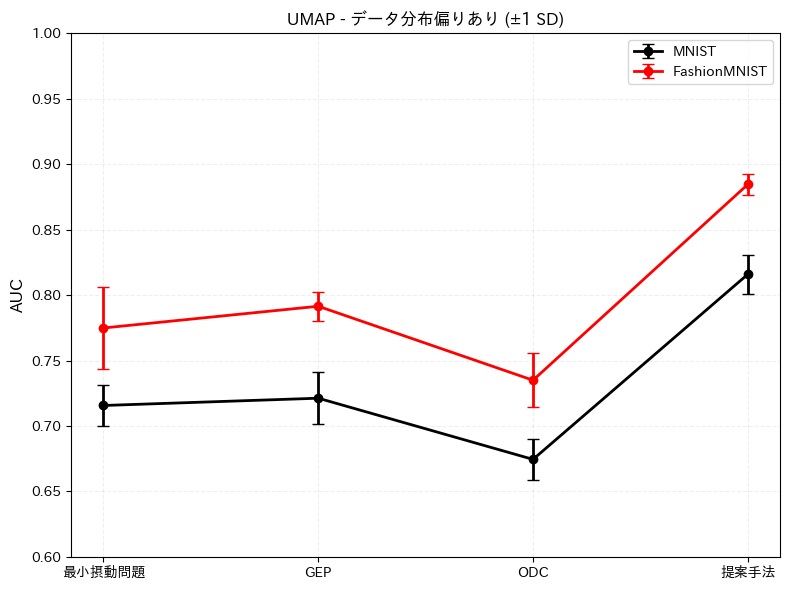

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df_mnist = pd.read_csv("result_grid_mnist_中間発表.csv")
df_fashion = pd.read_csv("result_grid_fashion_mnist_中間発表.csv")

# Filter: UMAP + SMOTE + bias
cond = (df_mnist['F_type']=="umap") & (df_mnist['anchor_method']=="smote") & (df_mnist['data_distribution']=="bias")
sub_mnist = df_mnist[cond].copy()

cond2 = (df_fashion['F_type']=="umap") & (df_fashion['anchor_method']=="smote") & (df_fashion['data_distribution']=="bias")
sub_fashion = df_fashion[cond2].copy()

# Label mapping for G_type
gtype_map = {
    "Imakura": "最小摂動問題",
    "GEP": "GEP",
    "ODC": "ODC",
    "nonlinear": "提案手法"
}
order = ["最小摂動問題", "GEP", "ODC", "提案手法"]

# Apply mapping
sub_mnist["G_type"] = sub_mnist["G_type"].map(gtype_map)
sub_fashion["G_type"] = sub_fashion["G_type"].map(gtype_map)

# Sorting
sub_mnist["order"] = sub_mnist["G_type"].apply(lambda x: order.index(x))
sub_fashion["order"] = sub_fashion["G_type"].apply(lambda x: order.index(x))

sub_mnist = sub_mnist.sort_values("order")
sub_fashion = sub_fashion.sort_values("order")

# Plot
plt.figure(figsize=(8,6))

plt.errorbar(sub_mnist["G_type"], sub_mnist["score_mean"], 
             yerr=sub_mnist["score_stdev"], fmt='o-', color="black", linewidth=2, capsize=4, label="MNIST")

plt.errorbar(sub_fashion["G_type"], sub_fashion["score_mean"], 
             yerr=sub_fashion["score_stdev"], fmt='o-', color="red", linewidth=2, capsize=4, label="FashionMNIST")

# Axes & labels
plt.ylim(0.6, 1.0)
plt.ylabel("AUC", fontsize=12)
plt.grid(alpha=0.2, linestyle='--')
plt.legend()
plt.title("UMAP - データ分布偏りあり (±1 SD)")

plt.tight_layout()
plt.show()


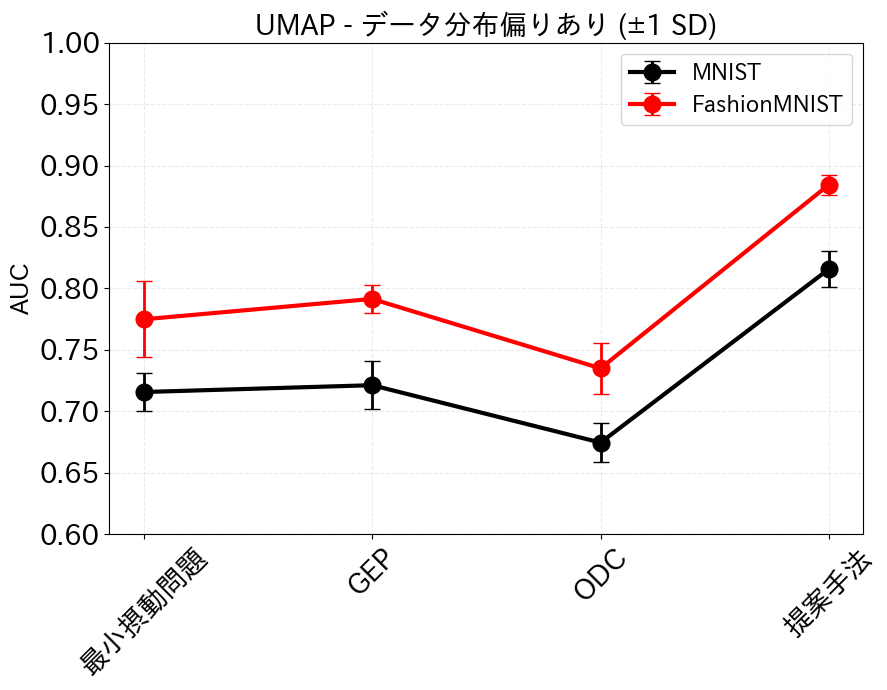

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df_mnist = pd.read_csv("result_grid_mnist_中間発表.csv")
df_fashion = pd.read_csv("result_grid_fashion_mnist_中間発表.csv")

# Filter
cond = (df_mnist['F_type']=="umap") & (df_mnist['anchor_method']=="smote") & (df_mnist['data_distribution']=="bias")
sub_mnist = df_mnist[cond].copy()

cond2 = (df_fashion['F_type']=="umap") & (df_fashion['anchor_method']=="smote") & (df_fashion['data_distribution']=="bias")
sub_fashion = df_fashion[cond2].copy()

# Label mapping
gtype_map = {
    "Imakura": "最小摂動問題",
    "GEP": "GEP",
    "ODC": "ODC",
    "nonlinear": "提案手法"
}
order = ["最小摂動問題", "GEP", "ODC", "提案手法"]

sub_mnist["G_type"] = sub_mnist["G_type"].map(gtype_map)
sub_fashion["G_type"] = sub_fashion["G_type"].map(gtype_map)

sub_mnist["order"] = sub_mnist["G_type"].apply(lambda x: order.index(x))
sub_fashion["order"] = sub_fashion["G_type"].apply(lambda x: order.index(x))

sub_mnist = sub_mnist.sort_values("order")
sub_fashion = sub_fashion.sort_values("order")

# Plot
plt.figure(figsize=(9,7))

plt.errorbar(sub_mnist["G_type"], sub_mnist["score_mean"], 
             yerr=sub_mnist["score_stdev"], fmt='o-', 
             color="black", linewidth=3, markersize=12, capsize=6, 
             elinewidth=2, label="MNIST")

plt.errorbar(sub_fashion["G_type"], sub_fashion["score_mean"], 
             yerr=sub_fashion["score_stdev"], fmt='o-', 
             color="red", linewidth=3, markersize=12, capsize=6,
             elinewidth=2, label="FashionMNIST")

plt.ylim(0.6, 1.0)
plt.ylabel("AUC", fontsize=18)
plt.yticks(fontsize=20)
plt.xticks(fontsize=20, rotation=45)
plt.grid(alpha=0.25, linestyle='--')

plt.legend(fontsize=16)
plt.title("UMAP - データ分布偏りあり (±1 SD)", fontsize=20)

plt.tight_layout()
plt.show()


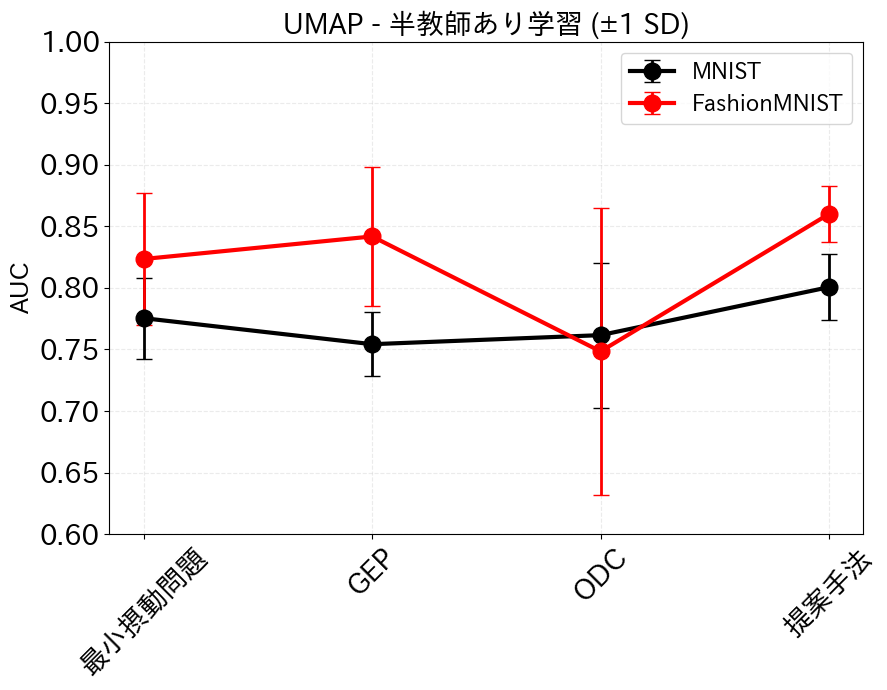

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df_mnist = pd.read_csv("result_grid_mnist_中間発表.csv")
df_fashion = pd.read_csv("result_grid_fashion_mnist_中間発表.csv")

# Filter
cond = (df_mnist['F_type']=="umap") & (df_mnist['anchor_method']=="smote") & (df_mnist['data_distribution']=="semi")
sub_mnist = df_mnist[cond].copy()

cond2 = (df_fashion['F_type']=="umap") & (df_fashion['anchor_method']=="smote") & (df_fashion['data_distribution']=="semi")
sub_fashion = df_fashion[cond2].copy()

# Label mapping
gtype_map = {
    "Imakura": "最小摂動問題",
    "GEP": "GEP",
    "ODC": "ODC",
    "nonlinear": "提案手法"
}
order = ["最小摂動問題", "GEP", "ODC", "提案手法"]

sub_mnist["G_type"] = sub_mnist["G_type"].map(gtype_map)
sub_fashion["G_type"] = sub_fashion["G_type"].map(gtype_map)

sub_mnist["order"] = sub_mnist["G_type"].apply(lambda x: order.index(x))
sub_fashion["order"] = sub_fashion["G_type"].apply(lambda x: order.index(x))

sub_mnist = sub_mnist.sort_values("order")
sub_fashion = sub_fashion.sort_values("order")

# Plot
plt.figure(figsize=(9,7))

plt.errorbar(sub_mnist["G_type"], sub_mnist["score_mean"], 
             yerr=sub_mnist["score_stdev"], fmt='o-', 
             color="black", linewidth=3, markersize=12, capsize=6, 
             elinewidth=2, label="MNIST")

plt.errorbar(sub_fashion["G_type"], sub_fashion["score_mean"], 
             yerr=sub_fashion["score_stdev"], fmt='o-', 
             color="red", linewidth=3, markersize=12, capsize=6,
             elinewidth=2, label="FashionMNIST")

plt.ylim(0.6, 1.0)
plt.ylabel("AUC", fontsize=18)
plt.yticks(fontsize=20)
plt.xticks(fontsize=20, rotation=45)
plt.grid(alpha=0.25, linestyle='--')

plt.legend(fontsize=16)
plt.title("UMAP - 半教師あり学習 (±1 SD)", fontsize=20)
plt.tight_layout()
plt.show()

